# 3D Reconstruction GAN — Volume Discriminator

This notebook implements your Phase 2 GAN strategy:

- Sparse GT slices → `Generator G` (pretrained `Fast2p5D`) → reconstructed slices
- `VolumeDiscriminator D` on **5-slice stacks** for z-axis consistency
- Two-phase training:
  1. Warm-up `D` with frozen `G` (5 epochs)
  2. Joint fine-tuning with `L_total = L_rec + λ_adv * L_adv`

`L_rec = MSE + (1 - SSIM) + FFT`, `L_adv` uses LSGAN (`MSE` on discriminator scores).

In [39]:
import random
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import nibabel as nib
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print('Device:', DEVICE)

CFG = {
    'data_root': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial',
    'img_size': 256,
    'in_channels': 5,
    'context_depth': 5,
    'stack_len': 5,
    'max_timepoints': 10,
    'batch_size': 2,
    'num_workers': 0,
    'warmup_d_epochs': 3,
    'joint_epochs': 8,
    'lr_d': 1e-4,
    'lr_g': 1e-5,
    'lambda_adv': 0.01,
    'joint_d_step_every': 10,
    'epoch_save_dir': 'models/epoch_saves',
    'disc_ckpt': 'models/D_joint_epoch_022.pth',
    'gen_ckpt': 'models/G_joint_epoch_022.pth',
}
print(CFG)

Device: mps
{'data_root': '/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial', 'img_size': 256, 'in_channels': 5, 'context_depth': 5, 'stack_len': 5, 'max_timepoints': 10, 'batch_size': 2, 'num_workers': 0, 'warmup_d_epochs': 3, 'joint_epochs': 8, 'lr_d': 0.0001, 'lr_g': 1e-05, 'lambda_adv': 0.01, 'joint_d_step_every': 10, 'epoch_save_dir': 'models/epoch_saves', 'disc_ckpt': 'models/D_joint_epoch_022.pth', 'gen_ckpt': 'models/G_joint_epoch_022.pth'}


In [40]:
def minmax_norm_2d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    if x_max - x_min < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min + eps)


def find_modality_file(timepoint_dir: Path, token: str) -> Path:
    files = sorted(timepoint_dir.glob('*.nii.gz'))
    if token == 'mask':
        candidates = [f for f in files if 'mask' in f.name.lower()]
    else:
        candidates = [f for f in files if token in f.name.lower()]
    if not candidates:
        raise FileNotFoundError(f'Could not find {token} in {timepoint_dir}')
    return candidates[0]


def load_timepoint_volumes(timepoint_dir: Path) -> Dict[str, np.ndarray]:
    paths = {
        't1n': find_modality_file(timepoint_dir, 't1n'),
        't1c': find_modality_file(timepoint_dir, 't1c'),
        't2w': find_modality_file(timepoint_dir, 't2w'),
        't2f': find_modality_file(timepoint_dir, 't2f'),
        'mask': find_modality_file(timepoint_dir, 'mask'),
    }
    vols = {k: nib.load(str(v)).get_fdata(dtype=np.float32) for k, v in paths.items()}
    base_shape = vols['t1n'].shape
    for k, v in vols.items():
        if v.shape != base_shape:
            raise ValueError(f'Shape mismatch in {timepoint_dir} for {k}: {v.shape} vs {base_shape}')
    return vols


def discover_timepoint_dirs(data_root: Path) -> List[Path]:
    timepoints: List[Path] = []
    for p in sorted(data_root.glob('PatientID_*')):
        if p.is_dir():
            for tp in sorted(p.glob('Timepoint_*')):
                if tp.is_dir():
                    timepoints.append(tp)
    if not timepoints:
        timepoints = sorted([p for p in data_root.rglob('Timepoint_*') if p.is_dir()])
    return timepoints


DATA_ROOT = Path(CFG['data_root'])
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Data root not found: {DATA_ROOT}')

ALL_TIMEPOINTS = discover_timepoint_dirs(DATA_ROOT)
if not ALL_TIMEPOINTS:
    raise RuntimeError('No timepoints found.')

TIMEPOINTS = ALL_TIMEPOINTS[:CFG['max_timepoints']]
print(f'Using {len(TIMEPOINTS)} timepoints out of {len(ALL_TIMEPOINTS)} discovered.')

Using 10 timepoints out of 15 discovered.


In [41]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNetDecoder2D(nn.Module):
    def __init__(self, in_ch: int = 128, out_ch: int = 1):
        super().__init__()
        self.enc1 = ConvBlock2D(in_ch, 128)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock2D(128, 256)
        self.bottleneck = ConvBlock2D(256, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = ConvBlock2D(512, 256)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = ConvBlock2D(256, 128)
        self.head = nn.Conv2d(128, out_ch, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.head(d1))


class SliceCNN2D(nn.Module):
    def __init__(self, in_ch: int = 5, out_ch: int = 96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 48, 3, padding=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
            nn.Conv2d(48, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Fast2p5D(nn.Module):
    def __init__(self, in_ch: int = 5, feat_ch: int = 96, out_ch: int = 1):
        super().__init__()
        self.slice_cnn = SliceCNN2D(in_ch=in_ch, out_ch=feat_ch)
        self.depth_attn = nn.Sequential(
            nn.Linear(feat_ch, feat_ch // 2),
            nn.ReLU(inplace=True),
            nn.Linear(feat_ch // 2, 1),
        )
        self.decoder = UNetDecoder2D(in_ch=feat_ch, out_ch=out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, d, h, w = x.shape
        feats = []
        for di in range(d):
            feats.append(self.slice_cnn(x[:, :, di, :, :]))
        feats = torch.stack(feats, dim=1)  # [B,D,F,H,W]
        depth_desc = feats.mean(dim=(3, 4))
        logits = self.depth_attn(depth_desc).squeeze(-1)
        alpha = torch.softmax(logits, dim=1)[:, :, None, None, None]
        fused = (feats * alpha).sum(dim=1)
        return self.decoder(fused)


class VolumeDiscriminator(nn.Module):
    # Input: [B, 5, H, W] -> internally [B,1,5,H,W]
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(32, 64, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv3d(64, 128, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
        )
        self.head = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1)  # [B,1,5,H,W]
        feat = self.net(x).flatten(1)
        return self.head(feat)


def load_generator(ckpt_path: Path) -> nn.Module:
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Generator checkpoint not found: {ckpt_path}')

    g = Fast2p5D(in_ch=CFG['in_channels'], feat_ch=96, out_ch=1).to(DEVICE)
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    state_dict = {k.replace('module.', '', 1) if k.startswith('module.') else k: v for k, v in state_dict.items()}
    missing, unexpected = g.load_state_dict(state_dict, strict=False)
    print(f'Loaded G from {ckpt_path}')
    print(f'Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}')
    return g

def load_discriminator(ckpt_path: Path) -> nn.Module:
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Discriminator checkpoint not found: {ckpt_path}')

    d = VolumeDiscriminator().to(DEVICE)
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    state_dict = {k.replace('module.', '', 1) if k.startswith('module.') else k: v for k, v in state_dict.items()}
    missing, unexpected = d.load_state_dict(state_dict, strict=False)
    print(f'Loaded D from {ckpt_path}')
    print(f'Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}')
    return d

G = load_generator(Path(CFG['gen_ckpt']))
D = load_discriminator(Path(CFG['disc_ckpt']))

print('G params:', f"{sum(p.numel() for p in G.parameters()):,}")
print('D params:', f"{sum(p.numel() for p in D.parameters()):,}")

Loaded G from models/G_joint_epoch_022.pth
Missing keys: 0 | Unexpected keys: 0
Loaded D from models/D_joint_epoch_022.pth
Missing keys: 0 | Unexpected keys: 0
G params: 7,603,186
D params: 493,793


In [42]:
def make_known_mask_half_alternating(z_count: int) -> np.ndarray:
    known = np.zeros(z_count, dtype=bool)
    known[::2] = True
    if not known.any():
        known[0] = True
    return known


def make_known_mask_n_uniform(z_count: int, n_keep: int = 50) -> np.ndarray:
    n_keep = int(max(1, min(n_keep, z_count)))
    idx = np.unique(np.linspace(0, z_count - 1, num=n_keep, dtype=int))
    known = np.zeros(z_count, dtype=bool)
    known[idx] = True
    return known


def make_known_mask_random_fraction(z_count: int, frac: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_keep = int(max(1, min(z_count, round(z_count * frac))))
    idx = np.sort(rng.choice(np.arange(z_count), size=n_keep, replace=False))
    known = np.zeros(z_count, dtype=bool)
    known[idx] = True
    return known


def make_known_mask_center_block(z_count: int, n_keep: int = 25) -> np.ndarray:
    n_keep = int(max(1, min(n_keep, z_count)))
    start = max(0, (z_count - n_keep) // 2)
    known = np.zeros(z_count, dtype=bool)
    known[start:start + n_keep] = True
    return known


def build_sparse_known_masks(z_count: int) -> Dict[str, np.ndarray]:
    return {
        'A_half_alternating_all5': make_known_mask_half_alternating(z_count),
        'B_50_uniform_all5': make_known_mask_n_uniform(z_count, n_keep=50),
        'C_half_alternating_t1n_mask': make_known_mask_half_alternating(z_count),
        'D_random_30_all5': make_known_mask_random_fraction(z_count, frac=0.30, seed=SEED),
        'E_random_15_all5': make_known_mask_random_fraction(z_count, frac=0.15, seed=SEED + 1),
        'F_center_25_all5': make_known_mask_center_block(z_count, n_keep=25),
    }


def init_t1n_state_from_known(t1n_gt: np.ndarray, known_mask: np.ndarray) -> np.ndarray:
    h, w, z_count = t1n_gt.shape
    known_ids = np.where(known_mask)[0]
    if len(known_ids) == 0:
        raise ValueError('known_mask has no known slices')

    state = np.zeros_like(t1n_gt, dtype=np.float32)
    for z in range(z_count):
        if known_mask[z]:
            state[:, :, z] = t1n_gt[:, :, z]
        else:
            nearest = int(known_ids[np.argmin(np.abs(known_ids - z))])
            state[:, :, z] = t1n_gt[:, :, nearest]
    return state


def build_context_slice(
    vols: Dict[str, np.ndarray],
    t1n_state: np.ndarray,
    known_mask: np.ndarray,
    z_id: int,
    img_size: int,
    input_mode: str,
    use_pred_for_all_channels: bool = True,
) -> np.ndarray:
    z_max = vols['t1n'].shape[2] - 1
    z = int(np.clip(z_id, 0, z_max))

    mask_base = cv2.resize((vols['mask'][:, :, z] > 0).astype(np.float32), (img_size, img_size), interpolation=cv2.INTER_LINEAR)

    if known_mask[z]:
        t1n_base = cv2.resize(minmax_norm_2d(vols['t1n'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        if input_mode == 't1n_mask':
            zero = np.zeros_like(t1n_base, dtype=np.float32)
            c_t1n, c_t1c, c_t2w, c_t2f, c_msk = t1n_base, zero, zero, zero, mask_base
        else:
            c_t1n = t1n_base
            c_t1c = cv2.resize(minmax_norm_2d(vols['t1c'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            c_t2w = cv2.resize(minmax_norm_2d(vols['t2w'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            c_t2f = cv2.resize(minmax_norm_2d(vols['t2f'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            c_msk = mask_base
    else:
        pred_base = cv2.resize(minmax_norm_2d(t1n_state[:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        if input_mode == 't1n_mask':
            zero = np.zeros_like(pred_base, dtype=np.float32)
            c_t1n, c_t1c, c_t2w, c_t2f, c_msk = pred_base, zero, zero, zero, mask_base
        else:
            if use_pred_for_all_channels:
                c_t1n, c_t1c, c_t2w, c_t2f, c_msk = pred_base, pred_base, pred_base, pred_base, pred_base
            else:
                c_t1n = pred_base
                c_t1c = cv2.resize(minmax_norm_2d(vols['t1c'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_t2w = cv2.resize(minmax_norm_2d(vols['t2w'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_t2f = cv2.resize(minmax_norm_2d(vols['t2f'][:, :, z]), (img_size, img_size), interpolation=cv2.INTER_LINEAR)
                c_msk = mask_base

    return np.stack([c_t1n, c_t1c, c_t2w, c_t2f, c_msk], axis=0).astype(np.float32)  # [5,H,W]


class SparseVolumeStackDataset(Dataset):
    # returns:
    #   contexts: [T, C, D, H, W] where T=stack_len, C=5, D=5
    #   gt_stack: [T, H, W]
    #   variant_id: int
    def __init__(self, timepoints: List[Path], img_size: int = 256, stack_len: int = 5):
        self.img_size = img_size
        self.stack_len = stack_len

        self.variant_names = [
            'A_half_alternating_all5',
            'B_50_uniform_all5',
            'C_half_alternating_t1n_mask',
            'D_random_30_all5',
            'E_random_15_all5',
            'F_center_25_all5',
        ]
        self.variant_to_id = {v: i for i, v in enumerate(self.variant_names)}

        self.vol_cache: Dict[str, Dict[str, np.ndarray]] = {}
        self.records: List[Dict] = []

        for tp in timepoints:
            vols = load_timepoint_volumes(tp)
            self.vol_cache[str(tp)] = vols
            z_count = vols['t1n'].shape[2]
            if z_count < 10:
                continue

            max_z_start = z_count - (5 + stack_len)
            if max_z_start < 0:
                continue

            for variant_name in self.variant_names:
                for z_start in range(0, max_z_start + 1):
                    self.records.append({
                        'tp': str(tp),
                        'variant': variant_name,
                        'z_start': z_start,
                    })

        if not self.records:
            raise RuntimeError('SparseVolumeStackDataset is empty.')

        print(f'Dataset records: {len(self.records)}')

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec = self.records[idx]
        tp = rec['tp']
        variant_name = rec['variant']
        z_start = rec['z_start']

        vols = self.vol_cache[tp]
        z_count = vols['t1n'].shape[2]

        known_map = build_sparse_known_masks(z_count)
        known_mask = known_map[variant_name]

        input_mode = 't1n_mask' if 't1n_mask' in variant_name else 'all5'

        t1n_state = init_t1n_state_from_known(vols['t1n'], known_mask)

        contexts = []
        gt_stack = []

        # target slices t = z_start+5 ... z_start+9 (5 consecutive)
        for t in range(z_start + 5, z_start + 5 + self.stack_len):
            z_ids = [t - 5, t - 4, t - 3, t - 2, t - 1]
            depth_items = [
                build_context_slice(vols, t1n_state, known_mask, zi, self.img_size, input_mode)
                for zi in z_ids
            ]
            # [D,C,H,W] -> [C,D,H,W]
            x_dc = np.stack(depth_items, axis=0).astype(np.float32)
            x = np.transpose(x_dc, (1, 0, 2, 3)).astype(np.float32)
            contexts.append(x)

            gt_slice = cv2.resize(minmax_norm_2d(vols['t1n'][:, :, t]), (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            gt_stack.append(gt_slice.astype(np.float32))

        contexts = np.stack(contexts, axis=0).astype(np.float32)   # [T,C,D,H,W]
        gt_stack = np.stack(gt_stack, axis=0).astype(np.float32)   # [T,H,W]

        return {
            'contexts': torch.from_numpy(contexts),
            'gt_stack': torch.from_numpy(gt_stack),
            'variant_id': torch.tensor(self.variant_to_id[variant_name], dtype=torch.long),
        }


dataset = SparseVolumeStackDataset(TIMEPOINTS, img_size=CFG['img_size'], stack_len=CFG['stack_len'])

n_total = len(dataset)
n_train = int(0.8 * n_total)
indices = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx = indices[n_train:]

train_ds = torch.utils.data.Subset(dataset, train_idx.tolist())
val_ds = torch.utils.data.Subset(dataset, val_idx.tolist())

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=CFG['num_workers'])
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

print(f'Train samples: {len(train_ds)} | Val samples: {len(val_ds)}')

Dataset records: 8760
Train samples: 7008 | Val samples: 1752


In [43]:
def ssim_global(x: torch.Tensor, y: torch.Tensor, c1: float = 0.01**2, c2: float = 0.03**2) -> torch.Tensor:
    # x,y: [N,1,H,W]
    mu_x = x.mean(dim=(2, 3), keepdim=True)
    mu_y = y.mean(dim=(2, 3), keepdim=True)
    var_x = ((x - mu_x) ** 2).mean(dim=(2, 3), keepdim=True)
    var_y = ((y - mu_y) ** 2).mean(dim=(2, 3), keepdim=True)
    cov_xy = ((x - mu_x) * (y - mu_y)).mean(dim=(2, 3), keepdim=True)

    ssim_map = ((2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))
    return ssim_map.mean()


def fft_l1_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # pred,target: [B,T,H,W]
    pred_fft = torch.fft.rfft2(pred, dim=(-2, -1))
    targ_fft = torch.fft.rfft2(target, dim=(-2, -1))
    return torch.mean(torch.abs(pred_fft - targ_fft))


def reconstruction_loss(pred_stack: torch.Tensor, gt_stack: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
    # [B,T,H,W]
    mse = F.mse_loss(pred_stack, gt_stack)

    n = pred_stack.shape[0] * pred_stack.shape[1]
    pred_2d = pred_stack.reshape(n, 1, pred_stack.shape[-2], pred_stack.shape[-1])
    gt_2d = gt_stack.reshape(n, 1, gt_stack.shape[-2], gt_stack.shape[-1])
    ssim_term = 1.0 - ssim_global(pred_2d, gt_2d)

    fft_term = fft_l1_loss(pred_stack, gt_stack)
    total = mse + ssim_term + fft_term

    return total, {
        'mse': float(mse.item()),
        'ssim': float((1.0 - ssim_term).item()),
        'fft': float(fft_term.item()),
    }


def predict_stack_with_g(g_model: nn.Module, contexts: torch.Tensor) -> torch.Tensor:
    # contexts: [B,T,C,D,H,W] -> output [B,T,H,W]
    b, t, c, d, h, w = contexts.shape
    preds = []
    for ti in range(t):
        x = contexts[:, ti, :, :, :, :]   # [B,C,D,H,W]
        y = g_model(x).squeeze(1)          # [B,H,W]
        preds.append(y)
    return torch.stack(preds, dim=1)


def set_requires_grad(module: nn.Module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag


opt_D = torch.optim.Adam(D.parameters(), lr=CFG['lr_d'], betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=CFG['lr_g'], betas=(0.5, 0.999))
scheduler_G = CosineAnnealingLR(opt_G, T_max=20, eta_min=1e-5)
scheduler_D = CosineAnnealingLR(opt_D, T_max=20, eta_min=2e-6)

In [ ]:
def run_epoch_d_only(loader: DataLoader) -> Dict[str, float]:
    D.train()
    G.eval()

    total_loss = 0.0
    total_real = 0.0
    total_fake = 0.0
    n_batches = 0

    for batch in loader:
        contexts = batch['contexts'].to(DEVICE)   # [B,T,C,D,H,W]
        gt_stack = batch['gt_stack'].to(DEVICE)   # [B,T,H,W]

        with torch.no_grad():
            pred_stack = predict_stack_with_g(G, contexts)

        real_score = D(gt_stack)
        fake_score = D(pred_stack.detach())

        ones = torch.ones_like(real_score)
        zeros = torch.zeros_like(fake_score)

        loss_d = F.mse_loss(real_score, ones) + F.mse_loss(fake_score, zeros)

        opt_D.zero_grad(set_to_none=True)
        loss_d.backward()
        opt_D.step()

        total_loss += float(loss_d.item())
        total_real += float(real_score.mean().item())
        total_fake += float(fake_score.mean().item())
        n_batches += 1

    return {
        'loss_d': total_loss / max(1, n_batches),
        'real_score': total_real / max(1, n_batches),
        'fake_score': total_fake / max(1, n_batches),
    }


def run_epoch_joint(loader: DataLoader, d_step_every: int = 10) -> Dict[str, float]:
    D.train()
    G.train()

    total_loss_d = 0.0
    total_loss_g = 0.0
    total_loss_rec = 0.0
    total_loss_adv = 0.0
    total_psnr = 0.0
    n_batches = 0
    n_d_updates = 0

    for i, batch in enumerate(loader):
        contexts = batch['contexts'].to(DEVICE)   # [B,T,C,D,H,W]
        gt_stack = batch['gt_stack'].to(DEVICE)   # [B,T,H,W]

        # --- G step: every batch ---
        pred_stack = predict_stack_with_g(G, contexts)
        fake_score_for_g = D(pred_stack)

        loss_rec, rec_parts = reconstruction_loss(pred_stack, gt_stack)
        loss_adv = F.mse_loss(fake_score_for_g, torch.ones_like(fake_score_for_g))
        loss_g = loss_rec + CFG['lambda_adv'] * loss_adv

        opt_G.zero_grad(set_to_none=True)
        loss_g.backward()
        opt_G.step()
        scheduler_G.step()

        # --- D step: only every N batches (after warmup) ---
        if i % d_step_every == 0:
            with torch.no_grad():
                pred_det = predict_stack_with_g(G, contexts)

            real_score = D(gt_stack)
            fake_score = D(pred_det)
            ones = torch.ones_like(real_score)
            zeros = torch.zeros_like(fake_score)

            loss_d = F.mse_loss(real_score, ones) + F.mse_loss(fake_score, zeros)
            opt_D.zero_grad(set_to_none=True)
            loss_d.backward()
            opt_D.step()
            scheduler_D.step()

            total_loss_d += float(loss_d.item())
            n_d_updates += 1

        mse = F.mse_loss(pred_stack, gt_stack).item()
        psnr = 10.0 * np.log10(1.0 / max(mse, 1e-12))

        total_loss_g += float(loss_g.item())
        total_loss_rec += float(loss_rec.item())
        total_loss_adv += float(loss_adv.item())
        total_real += float(real_score.mean().item())
        total_fake += float(fake_score.mean().item())
        total_psnr += float(psnr)
        n_batches += 1
    print(f"LR G: {scheduler_G.get_last_lr()[0]:.2e}")
    print(f"LR D: {scheduler_D.get_last_lr()[0]:.2e}")

    return {
        'loss_d': total_loss_d / max(1, n_d_updates),
        'loss_g': total_loss_g / max(1, n_batches),
        'loss_rec': total_loss_rec / max(1, n_batches),
        'loss_adv': total_loss_adv / max(1, n_batches),
        'psnr': total_psnr / max(1, n_batches),
        'd_updates': n_d_updates,
        'real_score': total_real / max(1, n_batches),
        'fake_score': total_fake / max(1, n_batches),
    }


def save_models_for_epoch(phase: str, epoch: int):
    save_dir = Path(CFG['epoch_save_dir'])
    save_dir.mkdir(parents=True, exist_ok=True)

    g_path = save_dir / f'G_{phase}_epoch_{epoch:03d}.pth'
    d_path = save_dir / f'D_{phase}_epoch_{epoch:03d}.pth'

    torch.save({'model_state_dict': G.state_dict(), 'cfg': CFG, 'phase': phase, 'epoch': epoch}, g_path)
    torch.save({'model_state_dict': D.state_dict(), 'cfg': CFG, 'phase': phase, 'epoch': epoch}, d_path)

    print(f'Saved G: {g_path}')
    print(f'Saved D: {d_path}')


# --------- Phase 2 training strategy ---------
# 1) Freeze G backbone, warm-up D (D updates every batch)
set_requires_grad(G, False)
set_requires_grad(D, True)

history = []
for ep in range(1, CFG['warmup_d_epochs'] + 1):
    tr = run_epoch_d_only(train_loader)
    va = run_epoch_d_only(val_loader)
    row = {
        'phase': 'warmup_d',
        'epoch': ep,
        'train_loss_d': tr['loss_d'],
        'val_loss_d': va['loss_d'],
        'val_real_score': va['real_score'],
        'val_fake_score': va['fake_score'],
    }
    history.append(row)
    print(
        f"[Warmup D {ep:02d}/{CFG['warmup_d_epochs']}] "
        f"train D {tr['loss_d']:.4f} | val D {va['loss_d']:.4f} | "
        f"val real {va['real_score']:.4f} | val fake {va['fake_score']:.4f}"
    )
    save_models_for_epoch('warmup', ep)

# 2) Unfreeze G and train jointly (D updates every 10 batches)
set_requires_grad(G, True)
set_requires_grad(D, True)

for ep in range(1, CFG['joint_epochs'] + 1):
    tr = run_epoch_joint(train_loader, d_step_every=CFG['joint_d_step_every'])
    va = run_epoch_joint(val_loader, d_step_every=CFG['joint_d_step_every'])
    row = {
        'phase': 'joint',
        'epoch': ep,
        'train_loss_d': tr['loss_d'],
        'train_loss_g': tr['loss_g'],
        'train_loss_rec': tr['loss_rec'],
        'train_loss_adv': tr['loss_adv'],
        'train_psnr': tr['psnr'],
        'train_d_updates': tr['d_updates'],
        'val_loss_d': va['loss_d'],
        'val_loss_g': va['loss_g'],
        'val_loss_rec': va['loss_rec'],
        'val_loss_adv': va['loss_adv'],
        'val_psnr': va['psnr'],
        'val_d_updates': va['d_updates'],
    }
    history.append(row)
    print(
        f"[Joint {ep:02d}/{CFG['joint_epochs']}] "
        f"train PSNR {tr['psnr']:.2f} dB | val PSNR {va['psnr']:.2f} dB | "
        f"train G {tr['loss_g']:.4f} | val G {va['loss_g']:.4f} | "
        f"D updates train/val: {tr['d_updates']}/{va['d_updates']}"
    )
    save_models_for_epoch('joint', ep)

In [ ]:
@torch.no_grad()
def evaluate_by_variant(loader: DataLoader) -> Dict[str, Dict[str, float]]:
    G.eval()
    D.eval()

    id_to_variant = {i: n for n, i in dataset.variant_to_id.items()}
    stats: Dict[str, Dict[str, List[float]]] = {}

    for batch in loader:
        contexts = batch['contexts'].to(DEVICE)
        gt_stack = batch['gt_stack'].to(DEVICE)
        variant_ids = batch['variant_id'].cpu().numpy().tolist()

        pred_stack = predict_stack_with_g(G, contexts)

        real_score = D(gt_stack).squeeze(1).cpu().numpy()
        fake_score = D(pred_stack).squeeze(1).cpu().numpy()

        mse_each = torch.mean((pred_stack - gt_stack) ** 2, dim=(1, 2, 3)).cpu().numpy()
        psnr_each = [10.0 * np.log10(1.0 / max(float(m), 1e-12)) for m in mse_each]

        for i, vid in enumerate(variant_ids):
            vname = id_to_variant[int(vid)]
            if vname not in stats:
                stats[vname] = {'psnr': [], 'real_score': [], 'fake_score': []}
            stats[vname]['psnr'].append(float(psnr_each[i]))
            stats[vname]['real_score'].append(float(real_score[i]))
            stats[vname]['fake_score'].append(float(fake_score[i]))

    out: Dict[str, Dict[str, float]] = {}
    for v, d in stats.items():
        out[v] = {
            'psnr': float(np.mean(d['psnr'])),
            'real_score': float(np.mean(d['real_score'])),
            'fake_score': float(np.mean(d['fake_score'])),
            'score_gap': float(np.mean(d['real_score']) - np.mean(d['fake_score'])),
        }
    return out


variant_metrics = evaluate_by_variant(val_loader)
print('=== Variant-level comparison (prediction vs GT + discriminator) ===')
for v in sorted(variant_metrics.keys()):
    m = variant_metrics[v]
    print(
        f"{v:30s} | PSNR {m['psnr']:.2f} dB | "
        f"D(real) {m['real_score']:.4f} | D(fake) {m['fake_score']:.4f} | "
        f"gap {m['score_gap']:.4f}"
    )

In [ ]:
out_path = Path(CFG['disc_ckpt'])
out_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        'generator_state_dict': G.state_dict(),
        'discriminator_state_dict': D.state_dict(),
        'history': history,
        'variant_metrics': variant_metrics,
        'cfg': CFG,
    },
    out_path,
)

print(f'Saved joint GAN checkpoint bundle: {out_path}')
print(f'Warmup epochs: {CFG["warmup_d_epochs"]} | Joint epochs: {CFG["joint_epochs"]}')
print(f'lambda_adv used: {CFG["lambda_adv"]}')

# Qualitative example
## 3D visualization of reconstructed brain structure with an inspection volume of predicted MRIs

[export] pred_case_a shape: H=240 W=240 Z=155  ->  155 axial slices
[export] Saved 155 slices to /Users/enricotazzer/Desktop/ORACLE project/brain-gan-viewer/data/gan_slices
[spacing] pixel=1.000 mm  slice=1.000 mm

  Running generate_brain.py ...
[load] Found 155 slices in /Users/enricotazzer/Desktop/ORACLE project/brain-gan-viewer/data/gan_slices
[load] Volume shape: (155, 240, 240)
[mask] Computing Otsu threshold …
[mask] Binary closing …
[mask] Filling holes …
[mask] Keeping largest connected component …
[mask] Mask volume: 1523744 voxels
[mesh] Pre-smoothing mask field …
[mesh] Marching cubes …
[mesh] Raw mesh: 105970 verts, 211936 faces
[mesh] Taubin smoothing …
[mesh] Cleaning …
[mesh] Decimating to 180145 faces …
[mesh] Decimation warning: No module named 'fast_simplification' — skipping
[mesh] Sampling MRI intensity at vertices …
[mesh] Final mesh: 105970 verts, 211936 faces
[mesh] Exported /Users/enricotazzer/Desktop/ORACLE project/brain-gan-viewer/viewer/assets/brain_surface.

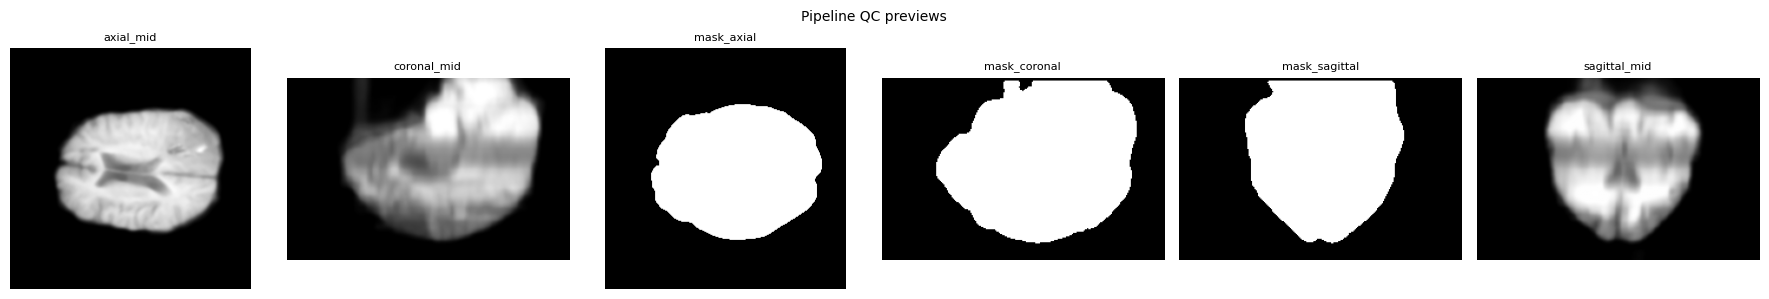

[server] Reusing existing server on port 7860


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Export GAN-generated slices to the brain-gan-viewer pipeline input
# ─────────────────────────────────────────────────────────────────────────────
import subprocess
import sys
import numpy as np
from pathlib import Path
from PIL import Image
from IPython.display import IFrame, display, HTML

# Resolve paths relative to this notebook
NOTEBOOK_DIR = Path('.').resolve()
PIPELINE_DIR = NOTEBOOK_DIR / 'brain-gan-viewer'
SLICES_DIR   = PIPELINE_DIR / 'data' / 'gan_slices'
SLICES_DIR.mkdir(parents=True, exist_ok=True)

# pred_case_a is (H, W, Z) float32 in [0, 1]
# Each axial slice is pred_case_a[:, :, z], saved as a grayscale PNG.
H, W, Z = pred_case_a.shape
print(f"[export] pred_case_a shape: H={H} W={W} Z={Z}  ->  {Z} axial slices")

# Clear any previous slices
for old in SLICES_DIR.glob("*.png"):
    old.unlink()

for z in range(Z):
    sl  = pred_case_a[:, :, z]                    # (H, W) float32 [0, 1]
    arr = np.clip(sl * 255.0, 0, 255).astype(np.uint8)
    arr = np.flipud(arr)                           # superior -> slice_000
    Image.fromarray(arr, mode='L').save(SLICES_DIR / f"slice_{z:03d}.png")

print(f"[export] Saved {Z} slices to {SLICES_DIR}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Derive voxel spacing from NIfTI header (falls back to 1 mm)
# ─────────────────────────────────────────────────────────────────────────────
try:
    _sp = voxel_spacing_zyx          # (dz, dy, dx) mm — defined in earlier cells
    pixel_spacing   = float(np.mean([_sp[1], _sp[2]]))
    slice_thickness = float(_sp[0])
except NameError:
    pixel_spacing   = 1.0
    slice_thickness = 1.0

print(f"[spacing] pixel={pixel_spacing:.3f} mm  slice={slice_thickness:.3f} mm")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Run generate_brain.py
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  Running generate_brain.py ...")
print("=" * 60)

gen_result = subprocess.run(
    [
        sys.executable, str(PIPELINE_DIR / 'generate_brain.py'),
        '--input_dir',         str(SLICES_DIR),
        '--output_dir',        str(PIPELINE_DIR),
        '--axis',              'axial',
        '--pixel_spacing',     str(pixel_spacing),
        '--slice_thickness',   str(slice_thickness),
        '--smooth_sigma',      '1.0',
        '--field_sigma',       '1.5',
        '--closing_radius',    '4',
        '--dilation_radius',   '1',
        '--taubin_iter',       '25',
        '--decimate_fraction', '0.85',
        '--max_slices',        str(Z),
    ],
)
if gen_result.returncode != 0:
    print(f"[error] generate_brain.py failed (exit {gen_result.returncode})")
else:
    print("[ok] generate_brain.py complete")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Copy viewer into docs/brain-viewer (GitHub Pages target)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  Running prepare_github_pages.py ...")
print("=" * 60)

pages_result = subprocess.run(
    [
        sys.executable, str(PIPELINE_DIR / 'prepare_github_pages.py'),
        '--viewer_src', str(PIPELINE_DIR / 'viewer'),
        '--deploy_dst', str(NOTEBOOK_DIR / 'docs' / 'brain-viewer'),
        '--base_path',  '',
    ],
)
if pages_result.returncode != 0:
    print(f"[warning] prepare_github_pages.py exited {pages_result.returncode}")
else:
    print("[ok] Static viewer deployed to docs/brain-viewer/")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Quick 2-D QC previews inline
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

preview_dir = PIPELINE_DIR / 'viewer' / 'assets' / 'preview'
previews    = sorted(preview_dir.glob("*.png")) if preview_dir.exists() else []

if previews:
    ncols = min(len(previews), 6)
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * 3, 3))
    if ncols == 1:
        axes = [axes]
    for ax, p in zip(axes, previews[:6]):
        ax.imshow(np.array(Image.open(p).convert('L')), cmap='gray')
        ax.set_title(p.stem, fontsize=8)
        ax.axis('off')
    plt.suptitle('Pipeline QC previews', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("[qc] No previews found — check generate_brain.py output above")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Serve viewer locally and embed in notebook
# ─────────────────────────────────────────────────────────────────────────────
import socket, threading, http.server

VIEWER_PORT = 7860
VIEWER_ROOT = str(NOTEBOOK_DIR / 'docs' / 'brain-viewer')
INDEX_PATH  = NOTEBOOK_DIR / 'docs' / 'brain-viewer' / 'index.html'


def _port_free(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) != 0


if INDEX_PATH.exists():
    if _port_free(VIEWER_PORT):
        class _Handler(http.server.SimpleHTTPRequestHandler):
            def __init__(self, *args, **kwargs):
                super().__init__(*args, directory=VIEWER_ROOT, **kwargs)
            def log_message(self, *args):
                pass

        srv = http.server.HTTPServer(('', VIEWER_PORT), _Handler)
        threading.Thread(target=srv.serve_forever, daemon=True).start()
        print(f"\n[server] Viewer running at http://localhost:{VIEWER_PORT}")
    else:
        print(f"[server] Reusing existing server on port {VIEWER_PORT}")

    _link_html = (
        '<div style="background:#0a0a0f;border-radius:8px;padding:10px 14px;margin:8px 0">'
        '<span style="color:#7ec8c8;font-family:monospace;font-size:13px">'
        '3D Brain Viewer &nbsp;&rarr;&nbsp;'
        f'<a href="http://localhost:{VIEWER_PORT}" target="_blank" style="color:#4a9eff">'
        f'http://localhost:{VIEWER_PORT}'
        '</a></span></div>'
    )
    display(HTML(_link_html))
    display(IFrame(f"http://localhost:{VIEWER_PORT}", width="100%", height=720))

else:
    _err_html = (
        '<div style="background:#1a0808;border:1px solid #5a2020;border-radius:8px;'
        'padding:14px;color:#e87070;font-family:monospace;font-size:13px">'
        'docs/brain-viewer/index.html not found.<br>'
        'Check that generate_brain.py completed without errors above.'
        '</div>'
    )
    display(HTML(_err_html))
